<a href="https://colab.research.google.com/github/KeithRajbhandari/KRB-HTML/blob/main/Week_4_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please upload 'Mall_Customers.csv':


Saving Mall_Customers.csv to Mall_Customers (2).csv

--- Dataset Overview ---
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

--- Generating Demographics Visualizations ---


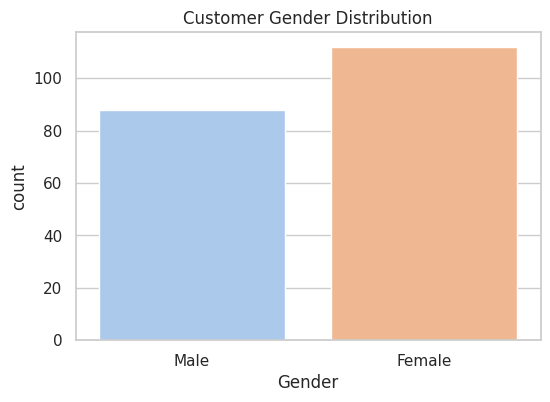

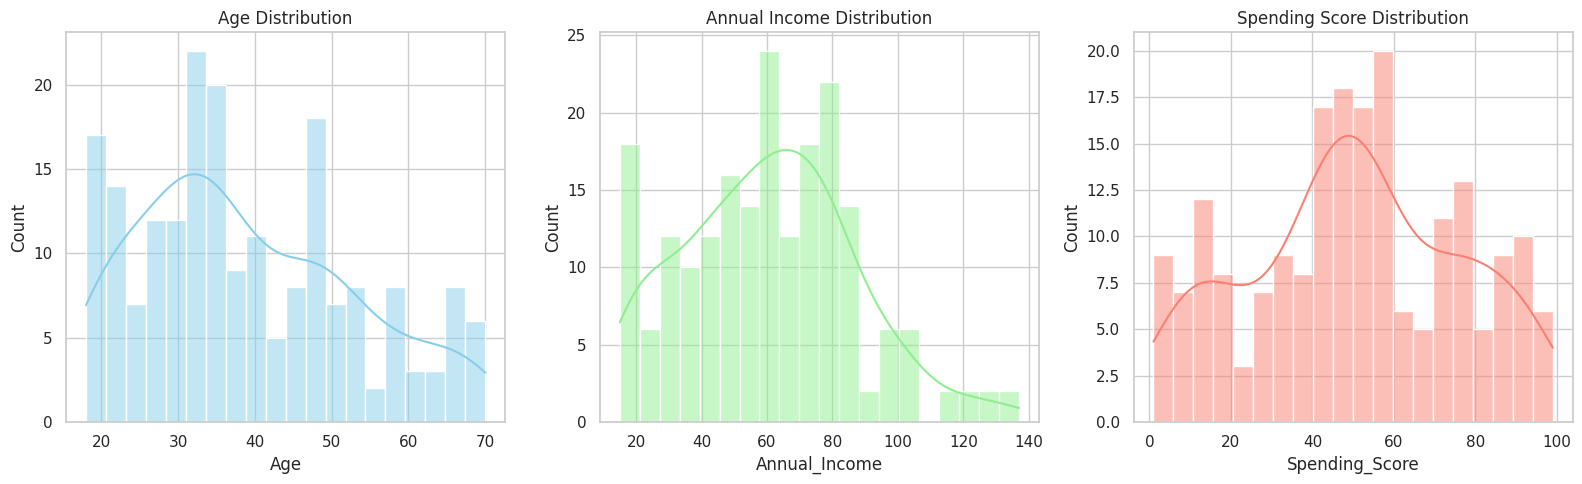

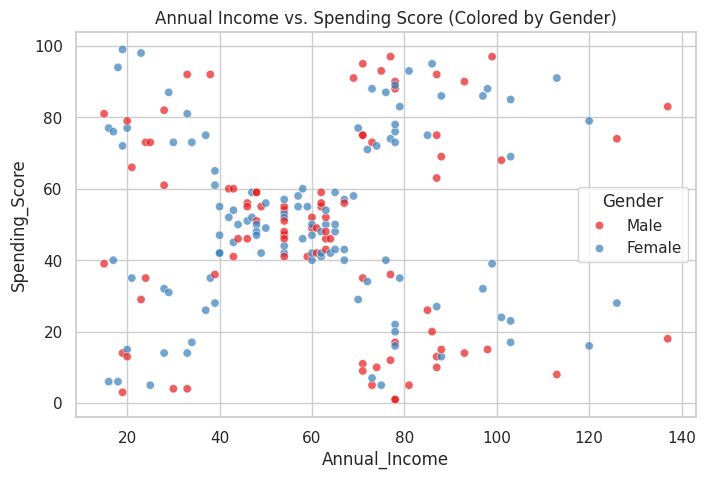


--- Running Machine Learning Clustering ---


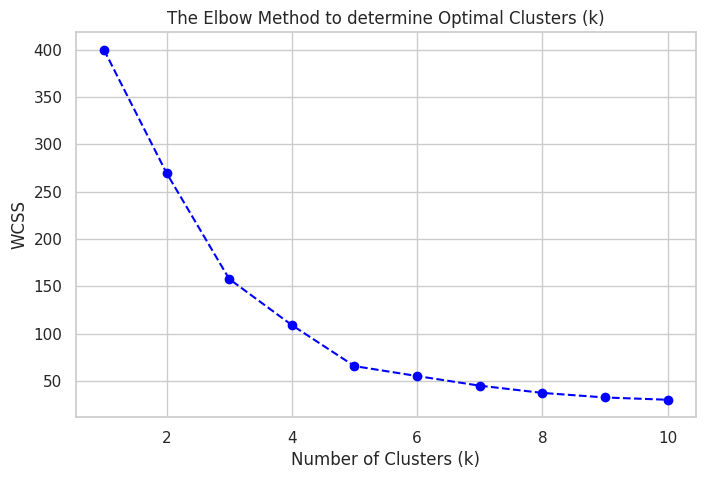


Model Evaluation - Silhouette Score: 0.5547
(A score closer to 1 indicates well-separated and distinct customer segments)


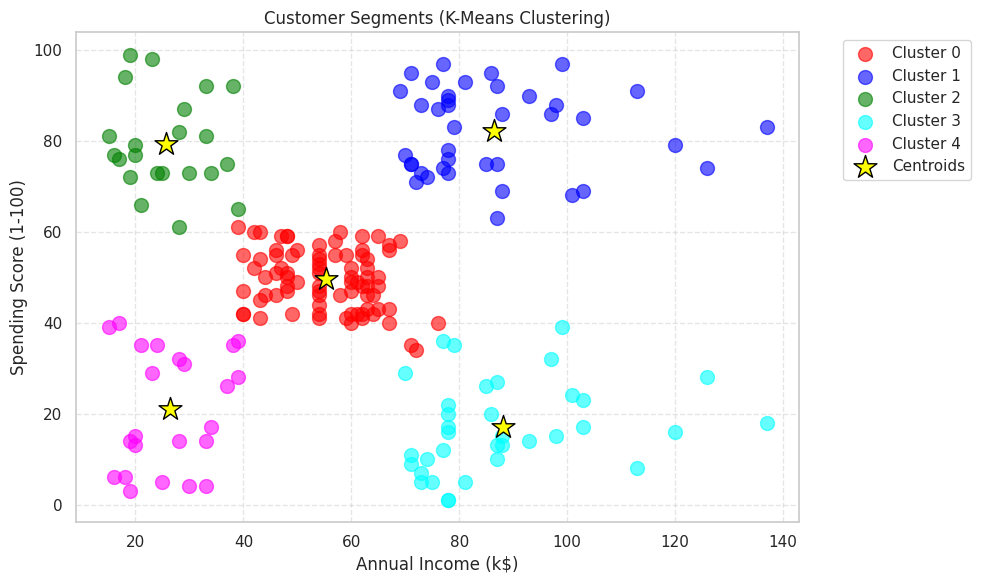


--- Final Business Customer Profiles ---
          Age  Annual_Income  Spending_Score
Cluster                                     
3        41.1           88.2            17.1
1        32.7           86.5            82.1
0        42.7           55.3            49.5
4        45.2           26.3            20.9
2        25.3           25.7            79.4


In [4]:
# ==============================================================================
# MASTER MALL CUSTOMER SEGMENTATION: EDA, K-MEANS CLUSTERING, & BUSINESS PROFILING
# ==============================================================================

# 1. SETUP & IMPORTS
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings

# Suppress minor warnings for clean output
warnings.filterwarnings('ignore')

# 2. FILE UPLOAD & LOADING
print("Please upload 'Mall_Customers.csv':")
uploaded = files.upload()

# Load the dataset referencing the exact file name
file_name = "Mall_Customers.csv"
df = pd.read_csv(file_name)

print("\n--- Dataset Overview ---")
print(df.head())

# Rename columns slightly to make coding easier
df.rename(columns={'Annual Income (k$)': 'Annual_Income',
                   'Spending Score (1-100)': 'Spending_Score'}, inplace=True)

# ==============================================================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ==============================================================================
print("\n--- Generating Demographics Visualizations ---")
sns.set_theme(style="whitegrid")

# Visual 1: Gender Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Gender', palette='pastel')
plt.title('Customer Gender Distribution')
plt.show()

# Visual 2: Age, Income, and Spending Score Distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.histplot(df['Age'], bins=20, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Age Distribution')
sns.histplot(df['Annual_Income'], bins=20, kde=True, color='lightgreen', ax=axes[1])
axes[1].set_title('Annual Income Distribution')
sns.histplot(df['Spending_Score'], bins=20, kde=True, color='salmon', ax=axes[2])
axes[2].set_title('Spending Score Distribution')
plt.tight_layout()
plt.show()

# Visual 3: Correlation between Age, Income, and Spending
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Annual_Income', y='Spending_Score', hue='Gender', palette='Set1', alpha=0.7)
plt.title('Annual Income vs. Spending Score (Colored by Gender)')
plt.show()

# ==============================================================================
# 4. DATA PREPROCESSING & THE ELBOW METHOD
# ==============================================================================
print("\n--- Running Machine Learning Clustering ---")

# Isolate features for clustering
X = df[['Annual_Income', 'Spending_Score']].values

# BEST PRACTICE: Scale the data for distance-based algorithms
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# The Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_scaled) # Using scaled data
    wcss.append(kmeans.inertia_)

# Visual 4: The Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='blue')
plt.title('The Elbow Method to determine Optimal Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.show()

# ==============================================================================
# 5. FINAL K-MEANS MODEL, SILHOUETTE SCORE & BUSINESS PROFILING
# ==============================================================================
# From the elbow curve, k=5 is typically optimal for this dataset
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=300, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled) # Predict using scaled data

# Attach clusters back to the original (unscaled) dataframe for readable reporting
df['Cluster'] = cluster_labels

# MODEL EVALUATION: Silhouette Score
sil_score = silhouette_score(X_scaled, cluster_labels)
print(f"\nModel Evaluation - Silhouette Score: {sil_score:.4f}")
print("(A score closer to 1 indicates well-separated and distinct customer segments)")

# Visual 5: Final Segmented Scatter Plot
plt.figure(figsize=(10, 6))
colors = ['red', 'blue', 'green', 'cyan', 'magenta']

for i in range(optimal_k):
    plt.scatter(X[cluster_labels == i, 0], X[cluster_labels == i, 1],
                s=100, c=colors[i], label=f"Cluster {i}", alpha=0.6)

# Plot Centroids (Inverse transform the scaled centroids back to original dollar/score values to plot correctly)
centroids_original_scale = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids_original_scale[:, 0], centroids_original_scale[:, 1],
            s=300, c='yellow', marker='*', edgecolor='black', label='Centroids')

plt.title('Customer Segments (K-Means Clustering)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Moves legend outside plot
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Final Business Report
print("\n--- Final Business Customer Profiles ---")
# Group by cluster to see the average age, income, and spending score of each group
cluster_summary = df.groupby('Cluster')[['Age', 'Annual_Income', 'Spending_Score']].mean().round(1)

# Sort by Income and Spending Score to make it easier to read the business logic
print(cluster_summary.sort_values(by=['Annual_Income', 'Spending_Score'], ascending=False))